# BEE 4750 Homework 1: Introduction to Using Julia

**Name**: William Dignam

**ID**: wed45, 5493731

> **Due Date**
>
> Thursday, 9/03/26, 9:00pm

## Overview

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [10]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `c:\Users\billy\OneDrive\Desktop\BEE 4750\HW1`
┌ Warning: The project dependencies or compat requirements have changed since the manifest was last resolved.
│ It is recommended to `Pkg.resolve()` or consider `Pkg.update()` if necessary.
└ @ Pkg.API C:\Users\billy\.julia\juliaup\julia-1.12.7+0.x64.w64.mingw32\share\julia\stdlib\v1.12\Pkg\src\API.jl:1322
Precompiling packages...
              ✗ MbedTLS
              ✗ HTTP
  0 dependencies successfully precompiled in 51 seconds. 258 already precompiled.
  209 dependencies precompiled but different versions are currently loaded (AbstractTrees, Adapt, Adapt → AdaptSparseArraysExt, Adapt → AdaptStaticArraysExt, AliasTables, ArgTools, ArnoldiMethod, AxisAlgorithms, Base64, Bzip2_jll, CSV, Cairo_jll, ChainRulesCore, ChainRulesCore → ChainRulesCoreSparseArraysExt, CodecZlib, ColorSchemes, ColorTypes, ColorVectorSpace, ColorVectorSpace → SpecialFunctionsExt, Colors, Compat, Compat → CompatLinearAlgebraExt, CompilerSuppor

Standard Julia practice is to load all needed packages at the top of a
file. If you need to load any additional packages in any assignments
beyond those which are loaded by default, feel free to add a `using`
statement, though [you may need to install the
package](https://viveks.me/environmental-systems-analysis/tutorials/julia-basics.html#package-management).

In [30]:
using Random # allows for random seed generation
using Plots # basic plotting: can also install and use other packages
using Graphs # for making graphs and networks
using GraphRecipes # basic graph generation
using LaTeXStrings # allows for LaTeX formatting in plots
using Distributions # sampling and fitting of probability distributions
using CSV # file I/O for CSV files
using DataFrames # data structure for tabular data

In [12]:
# this sets a random seed, which ensures reproducibility of random number generation. You should always set a seed when working with random numbers.
Random.seed!(1)

TaskLocalRNG()

## Problems (Total: 50 Points)

### Problem 1 (10)

***Systems Modeling***:

Three factories are discharging a chemical called Chlororadiated
Ureadicarboxyl (or CRUD) into the Riley River. The river inflow has a
volume of 500,000 m$^3$/d and a CRUD concentration of 0.2 mg/L. The
river velocity is 25 km/d.

- Factory 1 discharges $100,000 \text{m}^3$/ of effluent with a CRUD
  concentration of 10 mg/L;
- Factory 2 discharges $60,000 \text{m}^3$/ of effluent with a CRUD
  concentration of 20 mg/L;
- Factory 3 discharges $200,000 \text{m}^3$/ of effluent with a CRUD
  concentration of 8 mg/L.

CRUD decays in the river with a first order reaction rate
$k=0.45 \text{d}^{-1}$.

Environmental authorities have taken samples downriver of the three
factories and found that the CRUD concentration exceeds the regulatory
limit of 1 mg/L. CRUD can be removed at the source discharge at a cost
of $50E^2$ per $1000 \text{m}^3$ treated, where $E$ is the efficiency of
removal (the fraction of CRUD removed).

#### Problem 1.1 (2)

Draw a diagram of the river and factory system. Include definitions for
any notation you will use.

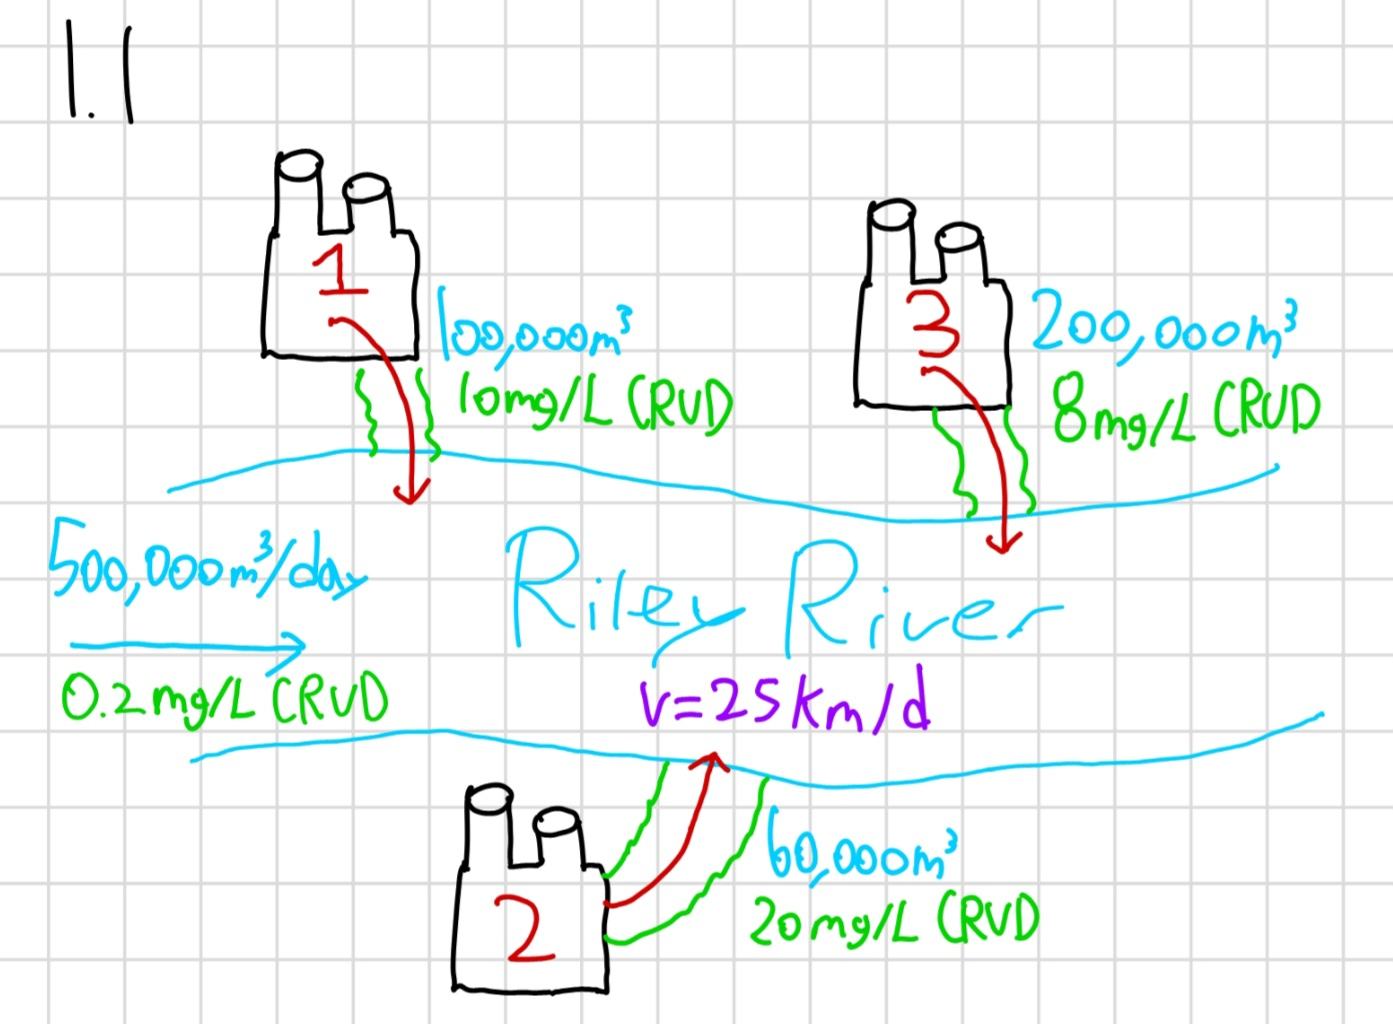

#### Problem 1.2 (5)

Write down a set of conditions on the removal efficiencies $E_1$, $E_2$,
and $E_3$ (where the subscript corresponds to the factory where the
effluent is being treated) to guarantee compliance.

Let $E_1$, $E_2$, and $E_3$ denote the fractions of CRUD removed from
the effluent of Factories 1, 2, and 3, respectively. 

Because $1\ \mathrm{mg/L}=1\ \mathrm{g/m^3}$, the incoming river carries

$$
(500{,}000)(0.2)=100{,}000\ \mathrm{g/day}
=100\ \mathrm{kg/day}
$$

of CRUD. The untreated factory loads are

$$
L_1=(100{,}000)(10)=1{,}000\ \mathrm{kg/day},
$$

$$
L_2=(60{,}000)(20)=1{,}200\ \mathrm{kg/day},
$$

and

$$
L_3=(200{,}000)(8)=1{,}600\ \mathrm{kg/day}.
$$

Immediately downstream of Factory 1, the concentration must satisfy

$$
\frac{100+1{,}000(1-E_1)}{600{,}000}
\left(1{,}000\ \frac{\mathrm{L}}{\mathrm{m^3}}\right)
\leq 1\ \mathrm{mg/L}.
$$

This simplifies to

$$
E_1 \geq 0.50.
$$

Immediately downstream of Factory 2, compliance requires

$$
100+1{,}000(1-E_1)+1{,}200(1-E_2)
\leq 660\ \mathrm{kg/day},
$$

or equivalently,

$$
1{,}000E_1+1{,}200E_2\geq1{,}640.
$$

Immediately downstream of Factory 3, compliance requires

$$
100+1{,}000(1-E_1)+1{,}200(1-E_2)
+1{,}600(1-E_3)
\leq860\ \mathrm{kg/day},
$$

or equivalently,

$$
1{,}000E_1+1{,}200E_2+1{,}600E_3\geq3{,}040.
$$

Therefore, a sufficient set of conditions guaranteeing compliance is

$$
{
\begin{aligned}
0 &\leq E_1,E_2,E_3\leq1,\\
E_1 &\geq0.50,\\
1{,}000E_1+1{,}200E_2 &\geq1{,}640,\\
1{,}000E_1+1{,}200E_2+1{,}600E_3 &\geq3{,}040.
\end{aligned}
}
$$

These conditions neglect first-order decay between
factories. Since decay only removes CRUD from the river, including it
would relax the required removal efficiencies.

#### Problem 1.3 (3)

Without finding an “optimal” solution, reason about which factories ought to treat their effluent at a higher level than the others. This can draw on considerations such as cost, the sequencing of discharges, and the amount of CRUD discharged by each factory, or others.

Considering treatment cost and CRUD discharged, Factory 2 should generally treat its
effluent at the highest level, followed by Factory 1 and then Factory 3.
The daily treatment costs for the three factories are 

$$
C_1=5{,}000E_1^2,\qquad
C_2=3{,}000E_2^2,\qquad
C_3=10{,}000E_3^2.
$$
(considering 50E^2 for every 1000m^3)

The quantities of CRUD removed are:

$$
R_1=1{,}000E_1,\qquad
R_2=1{,}200E_2,\qquad
R_3=1{,}600E_3.
$$

The marginal treatment cost per unit of CRUD removed is therefore (as a rate):

$$
\frac{dC_1/dE_1}{dR_1/dE_1}=10E_1,
\qquad
\frac{dC_2/dE_2}{dR_2/dE_2}=5E_2,
\qquad
\frac{dC_3/dE_3}{dR_3/dE_3}=12.5E_3.
$$

At equal removal efficiencies, Factory 2 has the lowest marginal cost
per unit of CRUD removed, followed by Factory 1 and then Factory 3.
Therefore, Factory 2 should generally treat its effluent at a higher
level. However, because each cost function is quadratic, additional
treatment does get more expensive, which is something to be considered in treatment for all three factories.

### Problem 2 (6)

***Systems Perturbations***:

Consider the perturbed phosphorous cycle example from Lecture 2. Now
suppose that the initial perturbation at $t=0$ is a 10% reduction in the
rate constant for the conversion of phosphorous from organic to
inorganic form (through an inhibition of phosphatase activity due to
e.g. acidic rain fall). When the new steady state is reached, how much
phosphorous will be in each compartment?

The phosphorus model is:

$$
{X_1}=\beta X_1X_2-\gamma X_1,
$$

$$
{X_2}=\alpha X_3-\beta X_1X_2,
$$

$$
{X_3}=\gamma X_1-\alpha X_3.
$$

The original steady-state concentrations are

$$
\overline{X}_1=0.2,\qquad
\overline{X}_2=0.1,\qquad
\overline{X}_3=1.0 
\ \ all \ in\ \ \mu\mathrm{mol/L}.
$$

The residence time of phosphorus in living biomass is four days.
Because the outflow from living biomass is $\gamma X_1$,

$$
\tau_1=\frac{X_1}{\gamma X_1}=\frac{1}{\gamma}=4,
$$

so

$$
\gamma=0.25\ \mathrm{day}^{-1}.
$$

At the original steady state (and considering t=0 initially),

$$
\beta\overline{X}_1\overline{X}_2
=\gamma\overline{X}_1,
$$

which gives

$$
\beta=\frac{\gamma}{\overline{X}_2}
=\frac{0.25}{0.1}
=2.5\ \mathrm{L}\,\mu\mathrm{mol}^{-1}\mathrm{day}^{-1}.
$$

Also,

$$
\alpha\overline{X}_3=\gamma\overline{X}_1,
$$

so

$$
\alpha
=\frac{\gamma\overline{X}_1}{\overline{X}_3}
=\frac{(0.25)(0.2)}{1.0}
=0.05\ \mathrm{day}^{-1}.
$$

A 10% reduction in $\alpha$ gives

$$
\alpha_{\mathrm{new}}
=0.90\alpha
=0.045\ \mathrm{day}^{-1}.
$$

At the new positive steady state,

$$
0=X_1(\beta X_2-\gamma),
$$

so

$$
X_2^*
=\frac{\gamma}{\beta}
=\frac{0.25}{2.5}
=0.1\ \mu\mathrm{mol/L}.
$$

The balance between living and dead organic phosphorus gives

$$
\alpha_{\mathrm{new}}X_3^*=\gamma X_1^*,
$$

and therefore

$$
X_3^*
=\frac{\gamma}{\alpha_{\mathrm{new}}}X_1^*
=\frac{0.25}{0.045}X_1^*
=\frac{50}{9}X_1^*.
$$

Because changing the rate constant does not add or remove phosphorus,
total phosphorus remains constant:

$$
X_1^*+X_2^*+X_3^*
=0.2+0.1+1.0
=1.3.
$$

Substituting $X_2^*=0.1$ and
$X_3^*=\frac{50}{9}X_1^*$ gives

$$
X_1^*+\frac{50}{9}X_1^*=1.2.
$$

Therefore,

$$
{X_1^*\approx0.1831\ \mu\mathrm{mol/L}},
$$

$$
{X_2^*=0.1000\ \mu\mathrm{mol/L}},
$$

and

$$
{X_3^*\approx1.0169\ \mu\mathrm{mol/L}}.
$$

Phosphorus accumulates slightly in dead organic matter, while phosphorus in
living biomass decreases. The inorganic phosphorus concentration
remains unchanged at the positive steady state because it is determined
by the ratio $\gamma/\beta$, both of which don't change

### Problem 3 (9)

***Debugging Code***:

The following subproblems all involve code snippets that require
debugging. You are encouraged to use online resources (*e.g.* Julia
documentation and forums, Stack Overflow, Reddit, etc) to help find
diagnose error messages and find solutions, but make sure that you
clearly document which resources you used and how you used them.

#### Problem 3.1 (3)

You’ve been tasked with writing code to identify the minimum value in an
array. You cannot use a predefined function. Your colleague suggested
the function below, but it does not return the minimum value.

In [13]:
function minimum(array)
    # initialize the minimum value counter
    min_value = array[1]
    # update minimum values
    for i in 1:length(array)
        if array[i] < min_value
            min_value = array[i]
        end
    end
    # return found minimum
    return min_value
end

array_values = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
@show minimum(array_values);

minimum(array_values) = 78


What is the logical flaw in the code? Fix it (describe what you changed
rather than reproducing the entire code snippet) and show that your
fixed code solves the problem.

Logical flaw / issue: All of the array values are positive numbers above the value "0". Therefore, "array[i] < min_value" will always be false, and the function will always return 0 even though 0 isn't even in the array. The solution is to make "min_value" equal to the first value in the array. The fixed code is above and returns "78" as the minimum value.

#### Problem 3.2 (3)

Your team wants to know the expected payout of an old Italian dice game
called *passadieci* (which was analyzed by Galileo as one of the first
examples of a rigorous study of probability). The goal of passadieci is
to get at least an 11 from rolling three fair, six-sided dice. Your
strategy is to compute the average wins from 1,000 trials, but the code
you’ve written below produces a `MethodError`.

In [22]:
# function to simulate a passadieci roll: 3 6-sided dice
function passadieci()
    # this rand() call samples 3 values from the vector [1, 6]
    roll = rand(1:6, 3) 
    return roll
end
# set number of trials and initialize outcome vector
n_trials = 1000
outcomes = zeros(n_trials)
# simulate number of passadieci rolls and count wins
for i = 1:n_trials
    outcomes[i] = (sum(passadieci()) >= 11)
end
win_prob = sum(outcomes) / n_trials # compute average number of wins
@show win_prob;

win_prob = 0.507


What does this `MethodError` mean? Why does this code produce one? Fix
the error (describe what you changed rather than reproducing the entire
code snippet) and solve the problem.

Logical flaw / issue: There are two issues in this code. "at least an 11" includes 11, so "sum(passadieci()) > 11" should be "sum(passadieci()) >= 11" to achieve probability with exactly 11 as well. Additionally, "zero" in julia only returns the integer value 0, which is the source of the MethodError. "outcomes" must be initialized as an array or vector for the indexed assignment outcomes[i] = ... inside the for loop to work. Otherwise, the loop attempts to assign a value to an indexed position in an integer, producing a MethodError. The solution is to change it to "zeros(n_trials)" to return a set vector, and the code above produces the solution ~0.5

#### Problem 3.3 (3)

You’re interested in writing some code to remove the mean of a vector
from all of its components. You’ve written the following code and tried
to test it on a random vector, but your code returns a `MethodError`.

In [26]:
# function to remove mean from a vector
function remove_mean(vect)
    # function to compute the mean
    function compute_mean(vect)
        element_sum = 0 # initialize sum
        # compute mean and return
        for v in vect
            element_sum += v
        end
        return element_sum / length(vect)
    end

    m = compute_mean(vect) # compute mean
    # return demeaned vector
    return vect .- m
end

random_vect = rand(1_000)
@show remove_mean(random_vect)

remove_mean(random_vect) = [-0.4750664987494184, 0.3062816921070738, 0.08515283003000862, 0.3109008138798066, -0.4289919275259876, -0.249130147408967, -0.06855867529345605, -0.04037863169466838, -0.13497452616683447, -0.03747781901678138, -0.05504188700817392, -0.36720078379566523, 0.3039145331399594, 0.50135621369716, -0.31982472867485423, -0.013385568790509672, 0.12847945778241399, -0.2278798987043842, 0.41862189766961444, -0.15124280698849712, 0.14923105457500796, 0.17535150198466054, -0.05425668814062845, -0.17886499967112257, 0.03905227048499249, 0.22080163802358654, 0.35682280994854987, -0.4540746390714877, 0.11900422067120942, -0.06545764949382504, 0.4042818483375745, -0.3543424581121052, 0.2720450877362739, 0.2709874869268504, -0.050765296983823704, -0.3488958108175809, 0.2510845561805607, -0.15764986633830924, 0.43284996170417034, -0.3630778824934998, 0.4645239336870748, -0.22865921791766197, -0.35975966991844355, -0.31643780710834535, -0.47033226622535684, 0.28479094658178794

1000-element Vector{Float64}:
 -0.4750664987494184
  0.3062816921070738
  0.08515283003000862
  0.3109008138798066
 -0.4289919275259876
 -0.249130147408967
 -0.06855867529345605
 -0.04037863169466838
 -0.13497452616683447
 -0.03747781901678138
 -0.05504188700817392
 -0.36720078379566523
  0.3039145331399594
  ⋮
 -0.4263861895444695
  0.42714856098416476
 -0.14220960329609256
  0.04726602597649732
  0.022466452771657708
  0.3587784126895489
  0.4736680301449798
 -0.23949598991395105
 -0.46047579925291815
  0.49879736520282425
 -0.17928148087113616
  0.47812228465539364

What does this `MethodError` mean? Why does this code produce one? Fix
the error (describe what you changed rather than reproducing the entire
code snippet) and solve the problem.

Logical flaw / issue: The line "return vect - m" is attempting to subtract a single number (m) from a vector (vect), which is not possible to directly compare. This is the MethodError issue in the code. As a solution, Julia has the capabilities to remove "m" from every element within the vector with proper syntax. The code above uses the proper Julia syntax (.-), and produces a value close to 0 within every element of the vector. This makes logical sense if you want to remove the mean of the vector from each element.

### Problem 4 (5)

***Loading and Manipulating Data***

The file `fha.csv` contains data[1] on the size of American metro areas
and the number of miles people drive in each metro area each day. This
problem asks you to load and work with this data to get practice with
data manipulation in Julia.

#### Problem 4.1 (2)

Load `fha.csv` into a Julia `DataFrame`. How many rows and columns does
the data have?  

Solution: 492 rows and 5 columns!

#### Problem 4.2 (3)

Calculate the number of miles driven per person per day for every metro
area. Make a scatterplot of this on the $y$-axis and the population of
the city on the $x$-axis. Make sure to label your axes and include a
caption clearly describing the plot. Highlight where the New York City
and Houston metro areas are on the plot and make a legend clearly
labelling any plot features.

In [ ]:
#Question 4.1

fha = CSV.read("data/fha.csv", DataFrame)

@show size(fha)

size(fha) = (492, 5)


(492, 5)

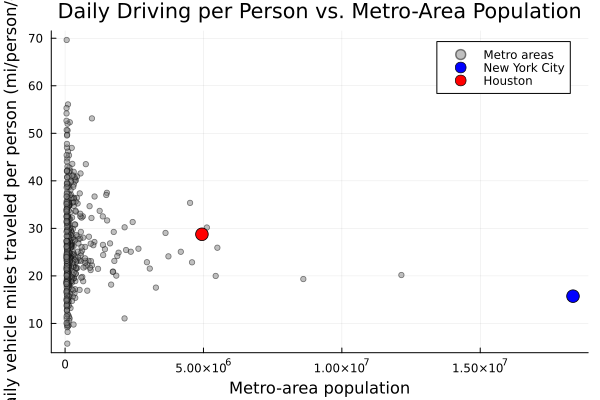

In [32]:
#Question 4.2
fha.miles_per_person_day =
    fha[!, "daily_vmt (mi/day)"] ./ fha.population


p = scatter(
    fha.population,
    fha.miles_per_person_day,
    label = "Metro areas",
    color = :gray,
    alpha = 0.5,
    markersize = 3,
    xlabel = "Metro-area population",
    ylabel = "Daily vehicle miles traveled per person (mi/person/day)",
    title = "Daily Driving per Person vs. Metro-Area Population"
)

nyc = occursin.("New York", fha.metro_area)
houston = occursin.("Houston", fha.metro_area)


scatter!(
    p,
    fha.population[nyc],
    fha.miles_per_person_day[nyc],
    label = "New York City",
    color = :blue,
    markersize = 7
)

scatter!(
    p,
    fha.population[houston],
    fha.miles_per_person_day[houston],
    label = "Houston",
    color = :red,
    markersize = 7
)

display(p)

### Problem 5 (20)

***Computational Modeling***:

Cheap Plastic Products, Inc. is operating a plant that produces
$100 \text{m}^3\text{/day}$ of wastewater that is discharged into
Pristine Brook. The wastewater contains $1 \text{kg/m}^3$ of YUK, a
toxic substance. The US Environmental Protection Agency has imposed an
effluent standard on the plant prohibiting discharge of more than
$20 \text{kg/day}$ of YUK into Pristine Brook.

Cheap Plastic Products has analyzed two methods for reducing its
discharges of YUK. Method 1 is land disposal, which costs $X_1^2/20$
dollars per day, where $X_1$ is the amount of wastewater disposed of on
the land ($\text{m}^3\text{/day}$). With this method, 20% of the YUK
applied to the land will eventually drain into the stream (*i.e.*, 80%
of the YUK is removed by the soil).

Method 2 is a chemical treatment procedure which costs \$1.50 per
$\text{m}^3$ of wastewater treated. The chemical treatment has an
efficiency of $e= 1 - 0.005X_2$, where $X_2$ is the quantity of
wastewater ($\text{m}^3\text{/day}$) treated. For example, if
$X_2 = 50 \text{m}^3\text{/day}$, then $e = 1 - 0.005(50) = 0.75$, so
that 75% of the YUK is removed.

Cheap Plastic Products is wondering how to allocate their wastewater
between these three disposal and treatment methods (land disposal,
chemical treatment, and direct disposal) to meet the effluent standard
while keeping costs manageable. The flow of wastewater through this
treatment system is shown in
<a href="#fig-wastewater" class="quarto-xref">Figure 1</a>.

[1] From the [2023 Federal Highway Administration’s Highway Statistics
report](https://www.fhwa.dot.gov/policyinformation/statistics/2023/pdf/hm72.pdf)

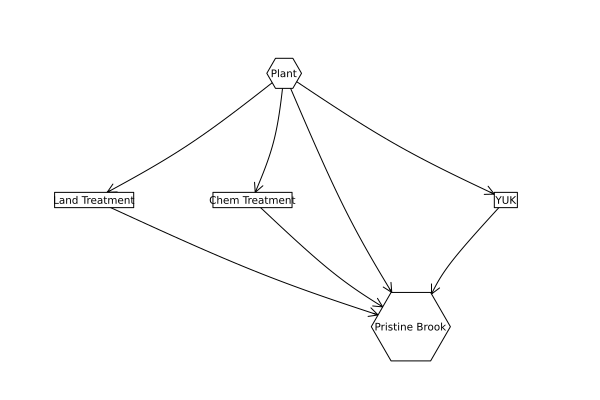

In [41]:
A = [0 1 1 1 1;
     0 0 0 1 0;
     0 0 0 1 0;
     0 0 0 0 0;
     0 0 0 1 0]

names = ["Plant", "Land Treatment", "Chem Treatment", "Pristine Brook", "YUK"]
# modify this dictionary to add labels
edge_labels = Dict((1, 2) => "", (1,3) => "", (1, 4) => "",(2, 4) => "",(3, 4) => "",(1, 5) => "",(5, 4) => "")
shapes=[:hexagon, :rect, :rect, :hexagon, :rect]
xpos = [0, -1.5, -0.25, 1, 1.75]
ypos = [1, 0, 0, -1, 0]

p = graphplot(A, names=names,edgelabel=edge_labels, markersize=0.15, markershapes=shapes, markercolor=:white, x=xpos, y=ypos)
display(p)

#### Problem 5.1 (2)

Make a figure showing notation for how YUK moves through the system for
a given treatment allocation. Make sure to define your variables. You
can make this by modifying the graph above or with an independent figure
included in your solution.

You can modify the edge labels (by editing the `edge_labels` dictionary
in the code) in
<a href="#fig-wastewater" class="quarto-xref">Figure 1</a> to show how
the wastewater allocations result in the final YUK discharge into
Pristine Brook. For the `edge_label` dictionary, the tuple $(i, j)$
corresponds to the arrow going from node $i$ to node $j$. The syntax for
any entry is `(i, j) => "label text"`, and the label text can include
mathematical notation if the string is prefaced with an `L`, as in
`L"x_1"` will produce $x_1$.

#### Problem 5.2 (4)

Formulate a mathematical model for the treatment cost and the amount of
YUK that will be discharged into Pristine Brook based on the wastewater
allocations. This is best done with some equations and supporting text
explaining the derivation. Make sure you include, as additional
equations in the model, any needed constraints on relevant values.

> **None**
>
> You can find some basics on writing mathematical equations using the
> LaTeX typesetting syntax
> [here](https://viveks.me/environmental-systems-analysis/tutorials/latex-notebook.qmd),
> and a cheatsheet with LaTeX commands can be found on the course
> website’s [Resources
> page](https://viveks.me/environmental-systems-analysis/resources/markdown.qmd).

Let $X_1$ represent wastewater sent to land disposal, $X_2$ represent
wastewater sent to chemical treatment, and $X_3$ represent wastewater
discharged directly to Pristine Brook, all in $\mathrm{m^3/day}$.

The total treatment cost is:

$$
C=\frac{X_1^2}{20}+1.50X_2.
$$

The chemical-treatment efficiency is:

$$
e=1-0.005X_2.
$$

Therefore, the total YUK discharge is:

$$
Y=0.2X_1+0.005X_2^2+X_3.
$$

Complete Mathematical Model:

$$
\begin{aligned}
\min_{X_1,X_2,X_3}\quad
&\frac{X_1^2}{20}+1.50X_2 \\[4pt]
\text{subject to}\quad
&X_1+X_2+X_3=100,\\
&0.2X_1+0.005X_2^2+X_3\leq20,\\
&X_1,X_2,X_3\geq0.
\end{aligned}
$$

#### Problem 5.3 (3)

Implement your systems model as a Julia function which computes the
resulting YUK discharge and cost for a particular treatment plan. You
can return multiple values from a function with a
[tuple](https://docs.julialang.org/en/v1/manual/functions/#Tuples-1), as
in:

In [ ]:
function multiple_return_values(x, y)
    return (x+y, x*y)
end

a, b = multiple_return_values(2, 5)
@show a;
@show b;

a = 7
b = 10

To evalute the function over vectors of inputs, you can *broadcast* the
function by adding a decimal `.` before the function arguments and
accessing the resulting values by writing a *comprehension* to loop over
the individual outputs in the vector:

In [ ]:
x = [1, 2, 3, 4, 5]
y = [6, 7, 8, 9, 10]

output = multiple_return_values.(x, y)
a = [out[1] for out in output]
b = [out[2] for out in output]
@show a;
@show b;

a = [7, 9, 11, 13, 15]
b = [6, 14, 24, 36, 50]

compliantCosts = [361.41892420129324, 399.4387913959372, 399.30782167667957, 363.43568869932005, 265.08640664509534, 421.8756020033286, 390.8233922659977, 437.6525217598731, 265.342957704057, 258.3404537659346, 425.060030935176, 282.22229823070865, 252.3035892080785, 252.3710904790684, 332.7329882060366, 328.5980581327737, 285.62152257750887]


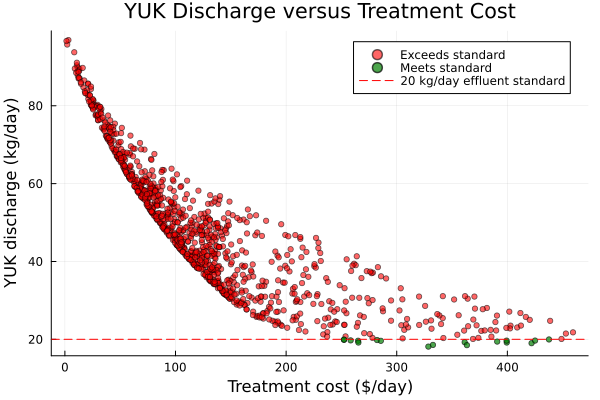

YUK discharge into Pristine Brook versus daily treatment cost for 1,000 randomly generated wastewater runs. Green points satisfy the 20 kg/day effluent standard, while red points exceed it. The dashed line represents the maximum permitted YUK discharge

In [54]:
# Compute YUK discharge and cost for one wastewater allocation/run
function treatment_model(x1, x2, x3)
    # YUK reaching the brook from each disposal method
    land_yuk = 0.20 * x1
    chemical_efficiency = 1 - 0.005 * x2
    chemical_yuk = (1 - chemical_efficiency) * x2
    direct_yuk = x3

    # Total YUK discharge in kg/day
    yuk_discharge = land_yuk + chemical_yuk + direct_yuk

    # Total treatment cost in dollars/day
    treatment_cost = x1^2 / 20 + 1.50 * x2

    return (yuk_discharge, treatment_cost)
end

#For 1000 Runs:
Random.seed!(1000)

# Each column is a run whose components add to 100 m³/day
runs = 100 .* rand(Dirichlet(ones(3)), 1000)

x1 = runs[1, :]  #land disposal
x2 = runs[2, :]  #chemical treatment
x3 = runs[3, :]  #direct discharge

#For combining results to all 1,000 runs
results = treatment_model.(x1, x2, x3)

yuk_discharge = [result[1] for result in results]
treatment_cost = [result[2] for result in results]

# Identify what meets the 20 kg/day standard
compliant = yuk_discharge .<= 20
compliantCosts = treatment_cost[compliant]
#@show results;
#@show compliant;
@show compliantCosts;


p = scatter(
    treatment_cost[.!compliant],
    yuk_discharge[.!compliant],
    label = "Exceeds standard",
    color = :red,
    alpha = 0.6,
    markersize = 3,
    xlabel = "Treatment cost (\$/day)",
    ylabel = "YUK discharge (kg/day)",
    title = "YUK Discharge versus Treatment Cost"
)

scatter!(
    p,
    treatment_cost[compliant],
    yuk_discharge[compliant],
    label = "Meets standard",
    color = :green,
    alpha = 0.7,
    markersize = 3
)

hline!(
    p,
    [20],
    label = "20 kg/day effluent standard",
    color = :red,
    linestyle = :dash
)

display(p)
print("YUK discharge into Pristine Brook versus daily treatment cost for 1,000 randomly generated wastewater runs. Green points satisfy the 20 kg/day effluent standard, while red points exceed it. The dashed line represents the maximum permitted YUK discharge")

(min_cost, min_cost_yuk) = (0.0, 100.0)
(min_yuk_cost, min_yuk) = (350.0, 18.0)


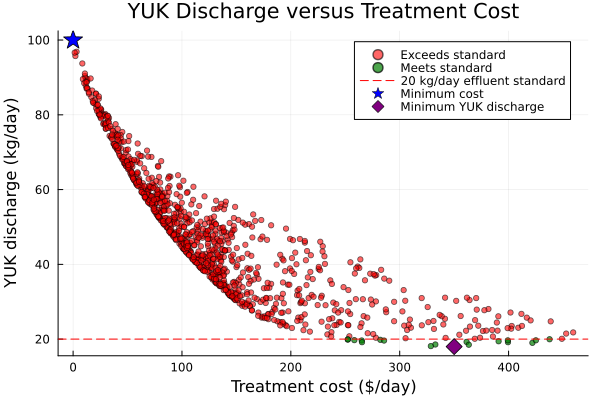

In [ ]:
#Question 5.6:

# Analytical minimum-cost strategy
min_cost_yuk, min_cost = treatment_model(0, 0, 100)

# Analytical minimum-YUK strategy
min_yuk, min_yuk_cost = treatment_model(80, 20, 0)

@show min_cost, min_cost_yuk
@show min_yuk_cost, min_yuk

scatter!(
    p,
    [min_cost],
    [min_cost_yuk],
    label = "Minimum cost",
    color = :blue,
    marker = :star5,
    markersize = 10
)

scatter!(
    p,
    [min_yuk_cost],
    [min_yuk],
    label = "Minimum YUK discharge",
    color = :purple,
    marker = :diamond,
    markersize = 8
)

display(p)

Make sure you comment your code appropriately to make it clear what is
going on and why.

Use your function to experiment with 1,000 different combinations of
wastewater discharge and treatment. You can do this with either a grid
search or by sampling from a [Dirichlet
distribution](https://en.wikipedia.org/wiki/Dirichlet_distribution) (a
$\text{Dirichlet}(1, n)$ distribution will generate uniformly-weighted
$n$-dimensional vectors whose components add up to 1; see the
[`Distributions.jl`
documentation](https://juliastats.org/Distributions.jl/stable/starting/)
for how to sample from probability distributions in Julia).

Plot the results of these experiments by making a scatterplot of YUK
discharge into the lake vs. treatment cost. Make sure to label your axes
and include a legend, as well as a caption clearly describing the plot.

#### Problem 5.4 (3)

Do any satisfy the YUK effluent standard (plot this as well as a dashed
red line). What was the cost of solutions satisfying the standard? 

Yes! Costs of solutions were between $252.3 and $437.65

 compliantCosts = [361.41892420129324, 399.4387913959372, 399.30782167667957, 363.43568869932005, 265.08640664509534, 421.8756020033286, 390.8233922659977, 437.6525217598731, 265.342957704057, 258.3404537659346, 425.060030935176, 282.22229823070865, 252.3035892080785, 252.3710904790684, 332.7329882060366, 328.5980581327737, 285.62152257750887]

#### Problem 5.5 (4)

What can you say about the tradeoff between treatment cost and YUK
discharge? You don’t have to find an “optimal” solution to this problem,
but what do you think would be needed to find a better solution?

The results show a clear tradeoff between treatment cost and YUK discharge. Less treatment is cheaper but releases more YUK, while greater treatment usually lowers discharge at a higher cost. However, spending more does not always produce a better result because the allocation between land disposal and chemical treatment also matters. A constrained optimization method could identify the lowest-cost plan that meets the 20 kg/day limit between YUK, land disposal, and chemical treatment altogether. 

#### Problem 5.6 (4)

Find the strategies which minimize cost and YUK discharge (these will be
different strategies) analytically and find the values of the objective
metrics. Plot these values in the plot that you created for Problem 4.3.
How do their values compare to the spread of values that you found in
that problem?

The wastewater allocations satisfy

$$
X_1+X_2+X_3=100,
\qquad X_1,X_2,X_3\geq0.
$$

The treatment cost is

$$
C=\frac{X_1^2}{20}+1.5X_2.
$$

Because both terms are nonnegative, cost is minimized when

$$
X_1=0,\qquad X_2=0,\qquad X_3=100.
$$

Therefore,

$$
{C_{\min}=0\ \text{dollars/day}}
$$

and the corresponding YUK discharge is

$$
Y=0.2(0)+0.005(0)^2+100
={100\ \text{kg/day}}.
$$

Minimum Cost: (0,0,100)

To minimize YUK discharge, substitute
$X_3=100-X_1-X_2$ into the discharge equation:

$$
Y=0.2X_1+0.005X_2^2+100-X_1-X_2.
$$

Thus,

$$
Y=100-0.8X_1-X_2+0.005X_2^2.
$$

For any fixed value of $X_2$, increasing $X_1$ lowers the discharge,
so the minimum occurs with no direct discharge:

$$
X_3=0,\qquad X_1=100-X_2.
$$

Substitution gives

$$
Y=20-0.2X_2+0.005X_2^2.
$$

Differentiating with respect to $X_2$ gives

$$
\frac{dY}{dX_2}=-0.2+0.01X_2.
$$

Setting this derivative equal to zero gives

$$
X_2=20.
$$

Therefore, the minimum-discharge allocation is

$$
X_1=80,\qquad X_2=20,\qquad X_3=0.
$$

Its objective values are

$$
{Y_{\min}=18\ \text{kg/day}}
$$

and

$$
C=\frac{80^2}{20}+1.5(20)
={350\ \text{dollars/day}}.
$$

This is plotted above! (before problem 5.4)

## References

List any external references consulted, including classmates.

Jasper Agrawal (ja627) helped me learn how Github works and how to connect a repository to Visual Studio code

Juliet Sencion (jas2224) and I completed the assignment on our own separately and then came together to compare answers and submit it together to Gradescope.

I used ChatGPT to help out on problem 5.3 for code syntax help with graphing arrays. Prompt: "what is wrong with my scatter plot code, why isn't YUK being graphed with colors indicating what is compliant. Also, what is the syntax for graphing a dashed line for 20kg/day" - I also attached photos of my formulas and code to the prompt as context for the AI to use in its answer

Syntax website I used as a resource for help: https://enccs.github.io/julia-intro/syntax-intro/ 

I consulted and referred to previous assignments I completed in CEE 3040 (Uncertainty Analysis in Engineering), which used LaTeX in Visual Studio Code, to ensure that my LaTeX syntax and formatting were correct.

For problem 3.3, I used AI overview for help:
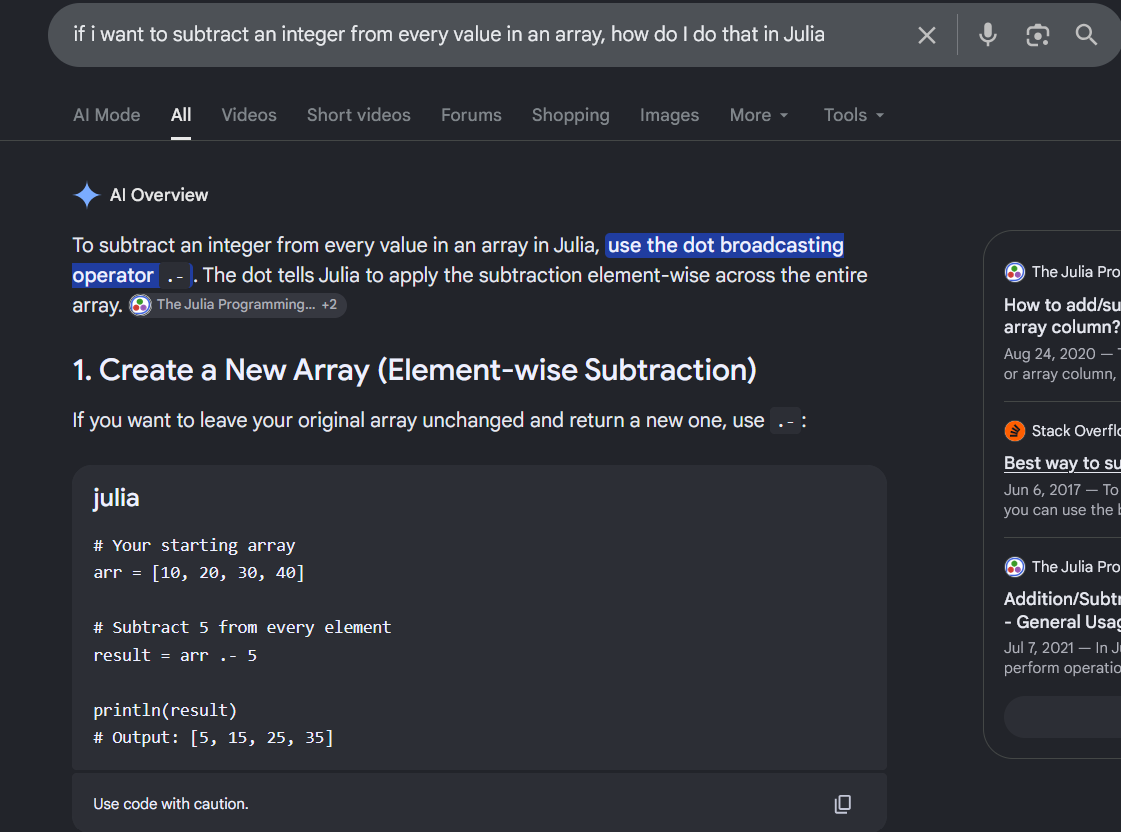